<a href="https://colab.research.google.com/github/16ajoop/Machine-Learning/blob/main/LNN_with_2_dense_layer(no_activation).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
TRAIN_DIR ="/content/drive/MyDrive/cats-dogs-classification/train"
TEST_DIR = "/content/drive/MyDrive/cats-dogs-classification/test"

In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import math

In [4]:
# ---- Config (reuse same directories/settings) ----
IMG_HEIGHT, IMG_WIDTH = 150, 150
IMG_CHANNELS = 3
BATCH_SIZE = 32
EPOCHS = 20

In [5]:
# ---- Load data ----
train_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.1, subset="training",
    seed=123, image_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE
)
val_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR, validation_split=0.1, subset="validation",
    seed=123, image_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE
)
test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR, image_size=(IMG_HEIGHT, IMG_WIDTH), batch_size=BATCH_SIZE, shuffle=False
)

CLASS_NAMES = train_ds.class_names
print("Classes:", CLASS_NAMES)

Found 1120 files belonging to 2 classes.
Using 1008 files for training.
Found 1120 files belonging to 2 classes.
Using 112 files for validation.
Found 280 files belonging to 2 classes.
Classes: ['cats', 'dogs']


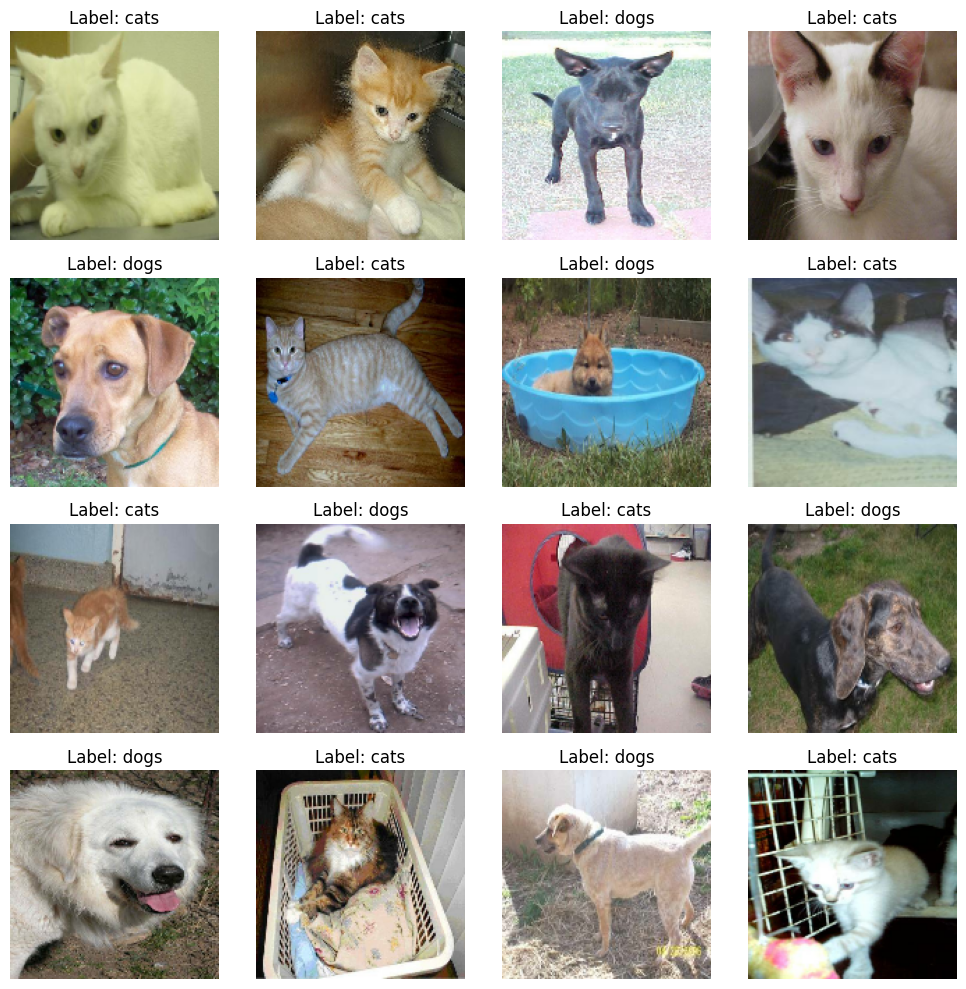

In [6]:
# ---- Peek at a batch of images before caching/prefetch changes anything ----
for image_batch, label_batch in train_ds.take(1):
    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    for i in range(16):
        ax = axes[i // 4, i % 4]
        ax.imshow(image_batch[i].numpy().astype("uint8"))
        ax.set_title(f"Label: {CLASS_NAMES[label_batch[i]]}")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

In [7]:
# ---- Performance: cache & prefetch ----
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)


In [11]:
linear_model = keras.Sequential([
    keras.layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
    keras.layers.Rescaling(1./255),      # normalize pixels 0-1
    keras.layers.Flatten(),               # turn image into 1D vector
    keras.layers.Dense(128),
    keras.layers.Dense(len(CLASS_NAMES), activation="softmax")  # one layer only
])

linear_model.compile(
    optimizer="adam",
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=["accuracy"]
)

linear_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 67500)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     8,640,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,640,386 (32.96 MB)

 Trainable params: 8,640,386 (32.96 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# ---- Train ----
history = linear_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

Epoch 1/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 95s 261ms/step - accuracy: 0.5000 - loss: 79.4444 - val_accuracy: 0.5982 - val_loss: 8.5377
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5298 - loss: 24.7844 - val_accuracy: 0.6250 - val_loss: 10.4296
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5575 - loss: 11.3745 - val_accuracy: 0.5179 - val_loss: 4.6972
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6190 - loss: 3.5651 - val_accuracy: 0.6161 - val_loss: 6.0588
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6002 - loss: 3.5220 - val_accuracy: 0.3929 - val_loss: 8.6211
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6458 - loss: 2.2148 - val_accuracy: 0.5357 - val_loss: 2.2072
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6776 - loss: 1.7942 - val_accuracy: 0.6071 - val_loss: 5.1346
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6359 - loss: 2.4953 - val_accuracy: 0.4286 - va

In [13]:
# ---- Evaluate ----
test_loss, test_acc = linear_model.evaluate(test_ds)
print(f"Linear model test accuracy: {test_acc:.4f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 48s 5s/step - accuracy: 0.5571 - loss: 1.0539
Linear model test accuracy: 0.5571


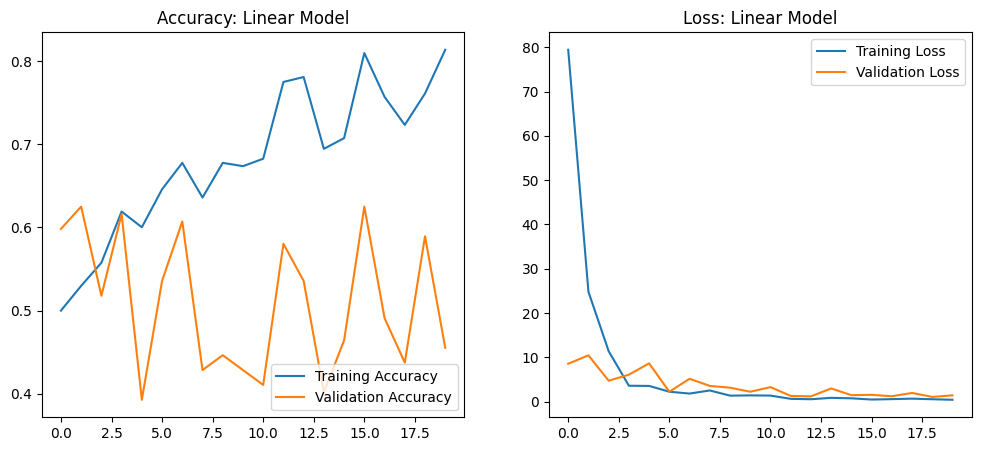

In [14]:
# ---- Plot training curves
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Accuracy: Linear Model')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Loss: Linear Model')

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step


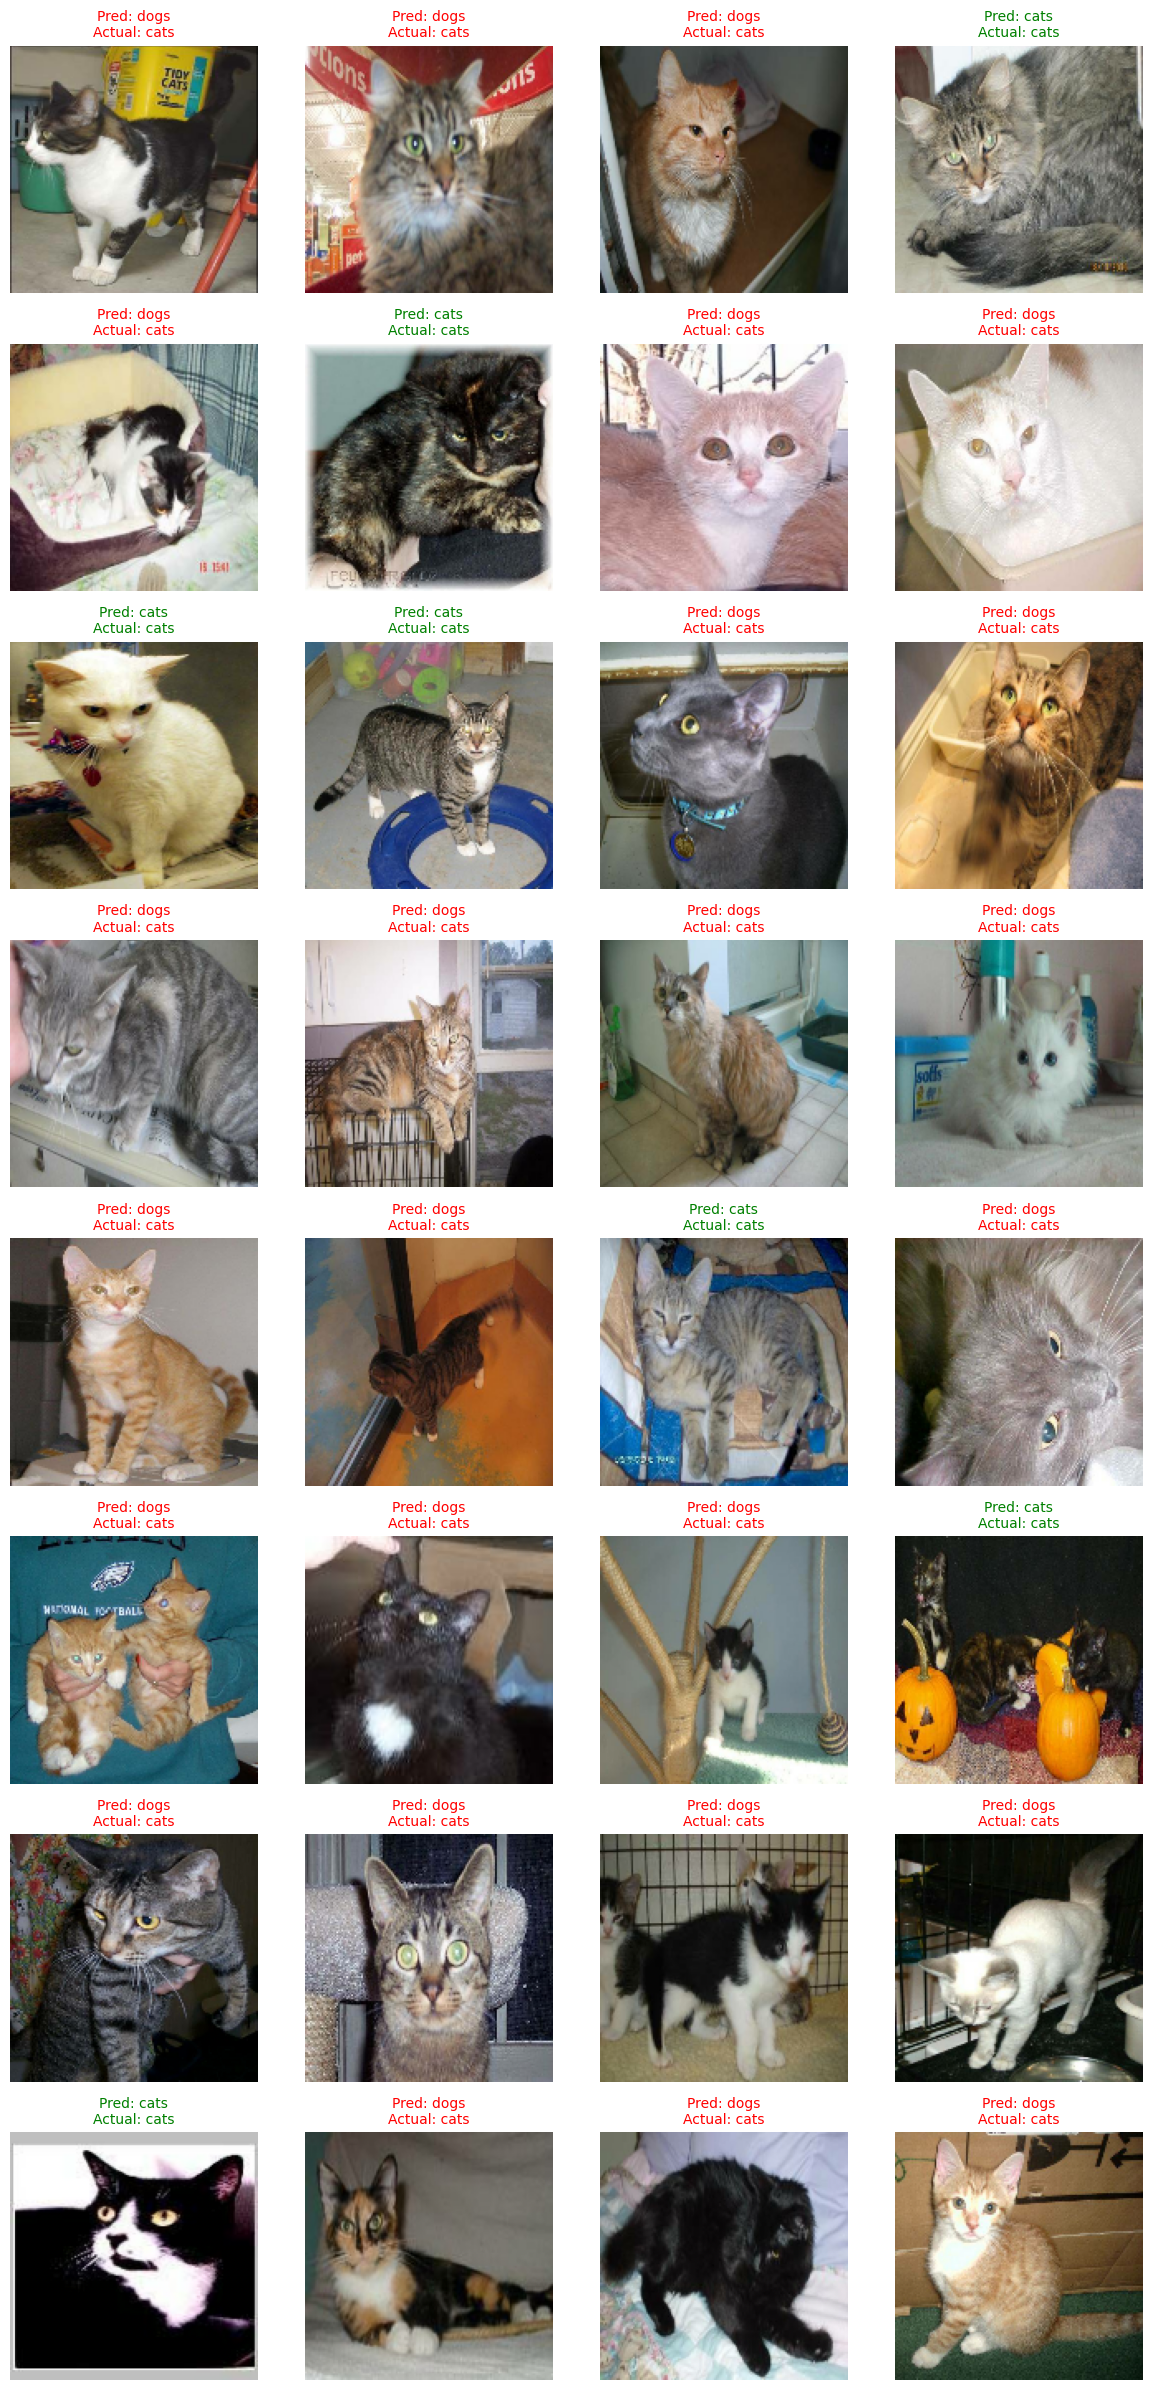

In [15]:
# ---- Predictions vs actual labels on a test batch ----
for images, labels in test_ds.take(1):
    batch_predictions = linear_model.predict(images)
    predicted_indices = np.argmax(batch_predictions, axis=1)

    num_images = images.shape[0]
    num_cols = 4
    num_rows = math.ceil(num_images / num_cols)

    plt.figure(figsize=(12, 3 * num_rows))

    for i in range(num_images):
        plt.subplot(num_rows, num_cols, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.axis('off')

        pred_class = CLASS_NAMES[predicted_indices[i]]
        actual_class = CLASS_NAMES[labels[i].numpy()]

        color = "green" if pred_class == actual_class else "red"
        plt.title(f"Pred: {pred_class}\nActual: {actual_class}", fontsize=10, color=color)

    plt.tight_layout()
    plt.show()